In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
games = pd.read_csv("../data/processed/game_lifecycle_clean.csv")

games.head()

,app_id,title,launch_price,reviews_total,review_score,tags,baseline_players,relative_6m,relative_12m,relative_24m,early_trend_slope,month_6_vs_month_1,early_volatility,early_peak_to_average
0,730,Counter-Strike: Global Offensive,14.99,7382695,0.88,"FPS, Shooter, Multiplayer, Competitive, Action...",13624.776667,1.210952,1.813688,9.060906,0.046684,1.085745,0.158598,1.177936
1,2870,X Rebirth,49.99,5102,0.41,"Simulation, Space, Sci fi, Action, Space Sim, ...",617.486667,0.594242,0.605125,0.315354,-0.176420,0.467198,0.602581,2.149940
2,4920,Natural Selection 2,9.99,8198,0.85,"Multiplayer, Strategy, FPS, Team Based, Action...",2238.970000,0.493038,0.330320,0.165360,-0.179528,0.324727,0.387130,1.605843
3,8870,BioShock Infinite,59.99,98966,0.93,"FPS, Story Rich, Action, Singleplayer, Steampu...",3600.803333,0.422417,0.548959,0.295640,-0.264835,0.173542,0.829654,2.649201
4,10270,Disciples III: Reincarnation,29.99,1066,0.69,"RPG, Strategy, Turn Based Strategy, Turn Based...",80.743333,0.653057,0.668868,0.615572,-0.146955,0.398816,0.375316,1.736611


In [3]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   app_id                 2542 non-null   int64  
 1   title                  2542 non-null   object 
 2   launch_price           2542 non-null   float64
 3   reviews_total          2542 non-null   int64  
 4   review_score           2542 non-null   float64
 5   tags                   2542 non-null   object 
 6   baseline_players       2542 non-null   float64
 7   relative_6m            2542 non-null   float64
 8   relative_12m           2542 non-null   float64
 9   relative_24m           2542 non-null   float64
 10  early_trend_slope      2542 non-null   float64
 11  month_6_vs_month_1     2542 non-null   float64
 12  early_volatility       2542 non-null   float64
 13  early_peak_to_average  2542 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 278.2+

## Lifecycle Categories
Declining: Relative24 < 0.5

Sustained: 0.5 ≤ Relative24 ≤ 1

Growing: Relative24 > 1

### Definition
Declining: activity after two years is less than half the early baseline.
Sustained: retains at least half of the early baseline.
Growing: has exceeded its early baseline after two years.

In [4]:
games["lifecycle_category"] = np.select([games["relative_24m"] < 0.5, games["relative_24m"] <= 1.0],
    ["Declining", "Sustained"], default="Growing"
)

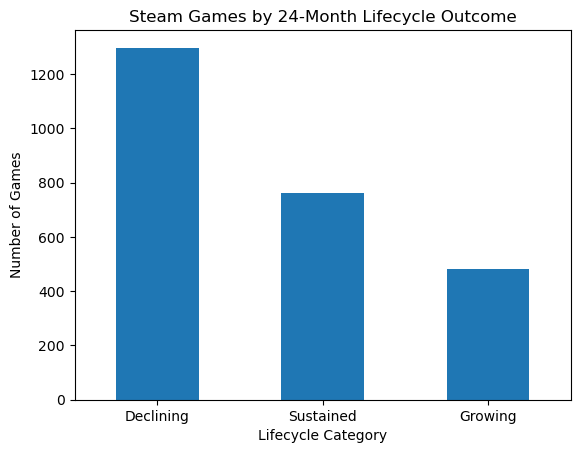

In [5]:
order = ["Declining", "Sustained", "Growing"]

category_counts = (games["lifecycle_category"].value_counts().reindex(order))

category_counts.plot(kind="bar")

plt.xlabel("Lifecycle Category")
plt.ylabel("Number of Games")
plt.title("Steam Games by 24-Month Lifecycle Outcome")
plt.xticks(rotation=0)

plt.show()

In [6]:
# Compare lifecycle trajectories across categories
trajectory_summary = (games.groupby("lifecycle_category")[["relative_6m", "relative_12m", "relative_24m"]]
    .median()
    .reindex(order)
)

trajectory_summary

,relative_6m,relative_12m,relative_24m
lifecycle_category,,,
Declining,0.492632,0.414213,0.288505
Sustained,0.673580,0.714188,0.673781
Growing,0.950482,1.232538,1.566771


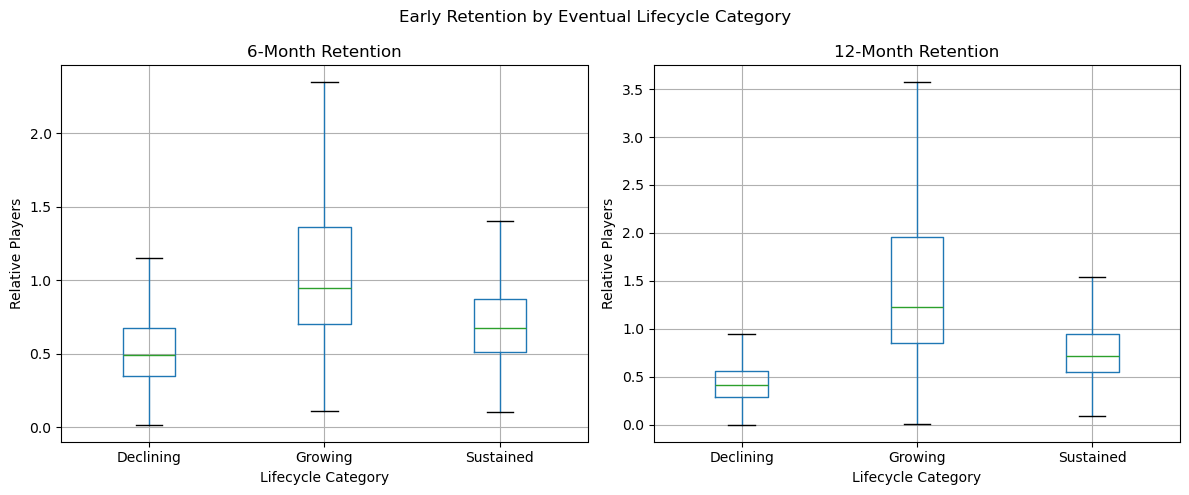

In [7]:
# Determine if actually separate or median have high overlap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ["relative_6m", "relative_12m"],
    ["6-Month Retention", "12-Month Retention"]
):
    games.boxplot(column=col, by="lifecycle_category", ax=ax, showfliers=False)

    ax.set_title(title)
    ax.set_xlabel("Lifecycle Category")
    ax.set_ylabel("Relative Players")

plt.suptitle("Early Retention by Eventual Lifecycle Category")
plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import kruskal

for col in ["relative_6m", "relative_12m"]:
    groups = [games.loc[games["lifecycle_category"] == category, col]
        for category in order
    ]

    stat, p = kruskal(*groups)

    print(f"{col}: H={stat:.2f}, p={p:.4g}")

# Player retention differs significantly across all lifecycle categories at 6 and 12 months

relative_6m: H=542.74, p=1.401e-118
relative_12m: H=1039.17, p=2.224e-226


In [9]:
from scipy.stats import spearmanr

for col in ["relative_6m", "relative_12m"]:
    rho, p = spearmanr(games[col], games["relative_24m"])

    print(
        f"{col} vs 24m: "
        f"rho={rho:.3f}, p={p:.4g}"
    )

# 6m retention was correlated with 24m retention and even stronger positive relationship at 12m

relative_6m vs 24m: rho=0.508, p=1.554e-166
relative_12m vs 24m: rho=0.701, p=0


Can conclude lifecycle definitions are meaningful and will continue using them in further analysis.

In [10]:
games.to_csv("../data/processed/game_lifecycle_classified.csv", index=False)